Lolwa Alboinin - 60106354 - section 1/2

# 1. Business Problem & Objectives

## Business Problem

Customer churn is a major issue in the telecommunications industry, as losing customers directly impacts revenue and profitability. This project aims to analyze customer behavior and predict which customers are likely to churn using demographic information, service usage data, and billing details. By identifying high-risk customers, the company can take proactive actions to improve customer retention and reduce financial loss.

## Project Objectives

The main objectives of this project are:

1. To analyze customer data and identify key factors that influence churn behavior.
2. To build a predictive machine learning model using AutoML to classify customers as churn or non-churn.
3. To explain the model’s predictions using SHAP to understand the most important features affecting churn.
4. To conduct bias analysis to ensure fairness in predictions across different customer groups.
5. To develop an interactive dashboard that presents insights and supports data-driven business decisions.

# 2. Dataset Description

## Dataset Overview

The dataset used in this project is the IBM Telco Customer Churn dataset. It contains 7,043 customer records and 20 features describing customer demographics, subscribed services, billing information, and churn status.

## Dataset Structure

The dataset was logically divided into three separate tables to satisfy the project requirement of using multiple data sources:

- **customers.csv**: Contains demographic information such as Gender, Senior Citizen status, Partner, and Dependents.
- **services.csv**: Contains service-related information including Internet Service type, Online Security, Streaming Services, and Technical Support.
- **billing.csv**: Contains contract details, payment methods, tenure in months, monthly charges, total charges, and churn label.

These tables were merged using the `CustomerID` field as the common key.

## Target Variable

The target variable for prediction is **Churn**, derived from the "Churn Label" column:

- **Yes (1)** → Customer has left the company.
- **No (0)** → Customer is still active.

This variable is used to train a classification model that predicts whether a customer is likely to churn.

In [1]:
!pip install --upgrade --force-reinstall numpy==1.26.4 pandas==2.2.2 shap

  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - --------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import shap

print(np.__version__)
print(pd.__version__)
print(shap.__version__)

1.26.4
2.2.2
0.49.1


In [3]:
import pandas as pd

# Load Excel file
df = pd.read_excel("../dataset/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
customers = df[[
    "CustomerID",
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents"
]]

customers.to_csv("../dataset/customers.csv", index=False)

In [5]:
services = df[[
    "CustomerID",
    "Phone Service",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]]

services.to_csv("../dataset/services.csv", index=False)

In [6]:
billing = df[[
    "CustomerID",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Tenure Months",
    "Churn Label"
]]

billing.to_csv("../dataset/billing.csv", index=False)

In [7]:
# Load the 3 files
customers = pd.read_csv("../dataset/customers.csv")
services = pd.read_csv("../dataset/services.csv")
billing = pd.read_csv("../dataset/billing.csv")

# Merge them step by step
df_merged = customers.merge(services, on="CustomerID")
df_merged = df_merged.merge(billing, on="CustomerID")

df_merged.head()

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Phone Service,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Tenure Months,Churn Label
0,3668-QPYBK,Male,No,No,No,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,Yes
1,9237-HQITU,Female,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2,Yes
2,9305-CDSKC,Female,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,8,Yes
3,7892-POOKP,Female,No,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,28,Yes
4,0280-XJGEX,Male,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,49,Yes


In [8]:
df_merged.info()
df_merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Phone Service      7043 non-null   object 
 6   Internet Service   7043 non-null   object 
 7   Online Security    7043 non-null   object 
 8   Online Backup      7043 non-null   object 
 9   Device Protection  7043 non-null   object 
 10  Tech Support       7043 non-null   object 
 11  Streaming TV       7043 non-null   object 
 12  Streaming Movies   7043 non-null   object 
 13  Contract           7043 non-null   object 
 14  Paperless Billing  7043 non-null   object 
 15  Payment Method     7043 non-null   object 
 16  Monthly Charges    7043 

,Monthly Charges,Tenure Months
count,7043.000000,7043.000000
mean,64.761692,32.371149
std,30.090047,24.559481
min,18.250000,0.000000
25%,35.500000,9.000000
50%,70.350000,29.000000
75%,89.850000,55.000000
max,118.750000,72.000000


In [9]:
df_merged["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
# Convert Senior Citizen Yes/No to 1/0
df_merged["Senior Citizen"] = df_merged["Senior Citizen"].map({"Yes": 1, "No": 0})

In [11]:
df_merged["Senior Citizen"].value_counts()

Senior Citizen
0    5901
1    1142
Name: count, dtype: int64

In [12]:
df_merged["Total Charges"] = pd.to_numeric(df_merged["Total Charges"], errors='coerce')

In [13]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Phone Service      7043 non-null   object 
 6   Internet Service   7043 non-null   object 
 7   Online Security    7043 non-null   object 
 8   Online Backup      7043 non-null   object 
 9   Device Protection  7043 non-null   object 
 10  Tech Support       7043 non-null   object 
 11  Streaming TV       7043 non-null   object 
 12  Streaming Movies   7043 non-null   object 
 13  Contract           7043 non-null   object 
 14  Paperless Billing  7043 non-null   object 
 15  Payment Method     7043 non-null   object 
 16  Monthly Charges    7043 




**Column: Churn Label**


Yes → Customer left the company (churned)

No → Customer is still active (did not churn)


# 3. Exploratory Data Analysis (EDA)

This section explores customer churn behavior using statistical summaries and group comparisons. The goal is to identify patterns and key drivers that may influence customer churn.

In [14]:
churn_rate = df_merged["Churn Label"].value_counts(normalize=True) * 100
churn_rate

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Approximately 26.5% of customers have churned, while 73.4% remain active. This indicates a moderate churn rate and highlights the importance of predicting at-risk customers to reduce revenue loss.

In [15]:
pd.crosstab(df_merged["Contract"], df_merged["Churn Label"], normalize='index') * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Customers with month-to-month contracts show a significantly higher churn rate (42.7%) compared to one-year (11.2%) and two-year contracts (2.8%). This suggests that longer-term contracts greatly reduce customer churn.

In [16]:
df_merged.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

Customers who churn tend to have higher monthly charges 74.44 compared to customers who remain 61.27, suggesting that higher pricing may contribute to customer attrition.

In [17]:
df_merged.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [18]:
# missing in Total Charges.
df_merged["Total Charges"] = df_merged["Total Charges"].fillna(df_merged["Total Charges"].median())

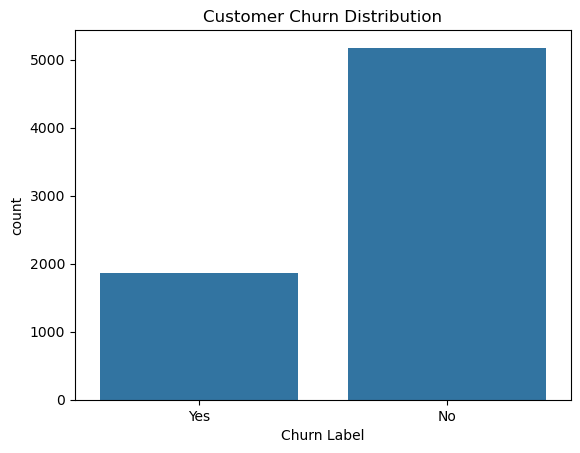

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn Label", data=df_merged)
plt.title("Customer Churn Distribution")
plt.show()

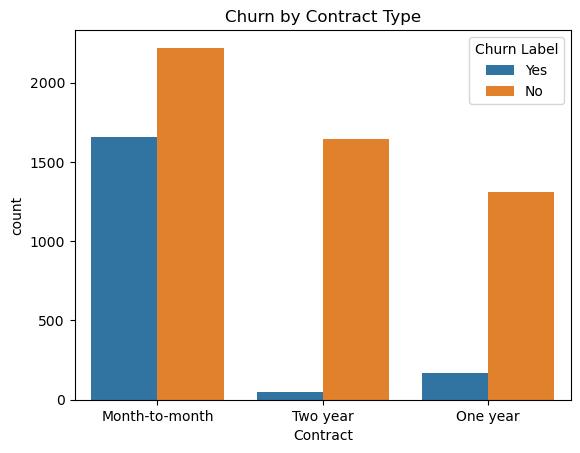

In [20]:
sns.countplot(x="Contract", hue="Churn Label", data=df_merged)
plt.title("Churn by Contract Type")
plt.show()

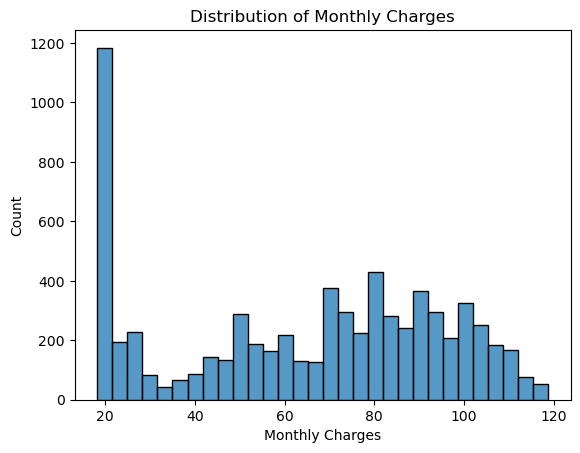

In [21]:
sns.histplot(df_merged["Monthly Charges"], bins=30)
plt.title("Distribution of Monthly Charges")
plt.show()

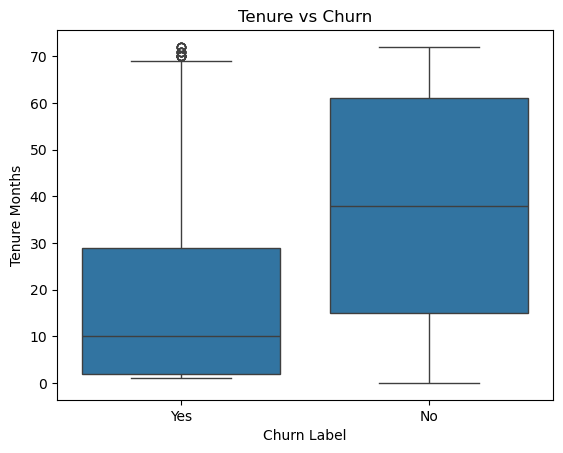

In [22]:
sns.boxplot(x="Churn Label", y="Tenure Months", data=df_merged)
plt.title("Tenure vs Churn")
plt.show()

<Axes: xlabel='Churn Label', ylabel='Monthly Charges'>

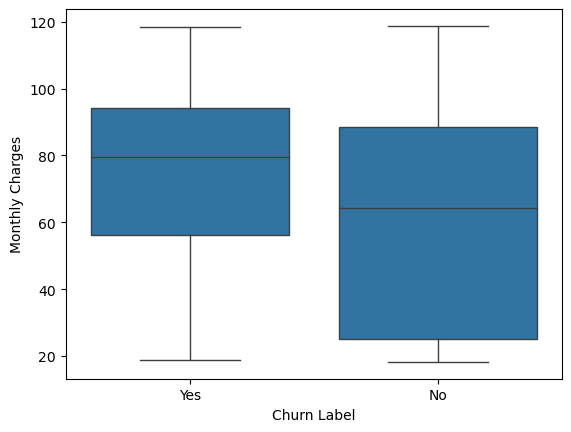

In [42]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)

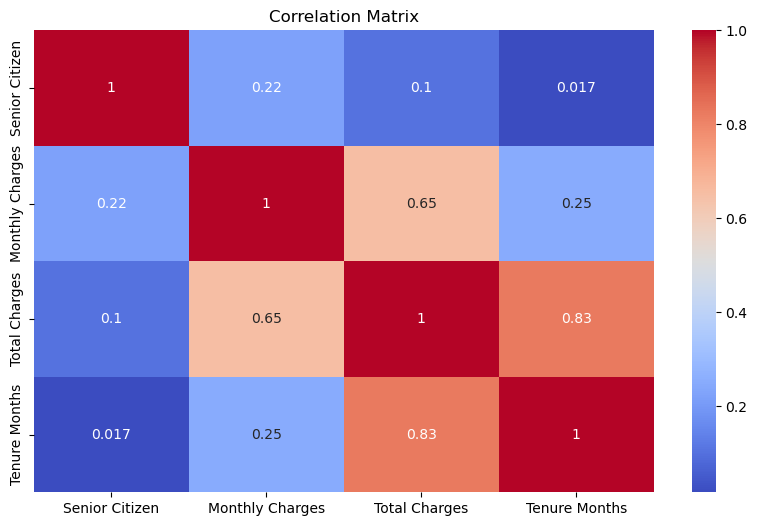

In [23]:
plt.figure(figsize=(10,6))
numeric_df = df_merged.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

## EDA Summary & Key Insights

The exploratory analysis revealed several important patterns:

- The overall churn rate is approximately **26.5%**, indicating a moderate level of customer attrition.
- Customers with **month-to-month contracts** have a significantly higher churn rate compared to customers with one-year or two-year contracts.
- Customers who churn have **higher average monthly charges**, suggesting that pricing may influence customer retention.
- Customers with **shorter tenure** are more likely to churn, indicating that new customers represent a higher churn risk.

These findings highlight that contract type, pricing, and customer tenure are strong indicators of churn behavior.

# 4. Feature Engineering & Data Preparation

In this section, the dataset is prepared for machine learning modeling. This includes encoding categorical variables, defining the target variable, and separating features (X) from the target (y).

In [24]:
# Encode target variable
df_merged["Churn"] = df_merged["Churn Label"].map({"Yes": 1, "No": 0})

df_merged["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [25]:
# Drop ID and original label column
df_model = df_merged.drop(columns=["CustomerID", "Churn Label"])

df_model.head()

,Gender,Senior Citizen,Partner,Dependents,Phone Service,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Tenure Months,Churn
0,Male,0,No,No,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,1
1,Female,0,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2,1
2,Female,0,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,8,1
3,Female,0,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,28,1
4,Male,0,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,49,1


In [26]:
# Convert categorical variables to numeric
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.shape

(7043, 29)

In [27]:
# Separate features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 28)
Target shape: (7043,)


## 5. Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 28)
Test shape: (1409, 28)


## 6. Model Development

The model used for prediction is Random Forest, which is an ensemble learning method. 
Random Forest builds multiple decision trees and combines their predictions to improve 
accuracy and reduce overfitting.

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7899219304471257
[[923 112]
 [184 190]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 8. Model Explainability using SHAP

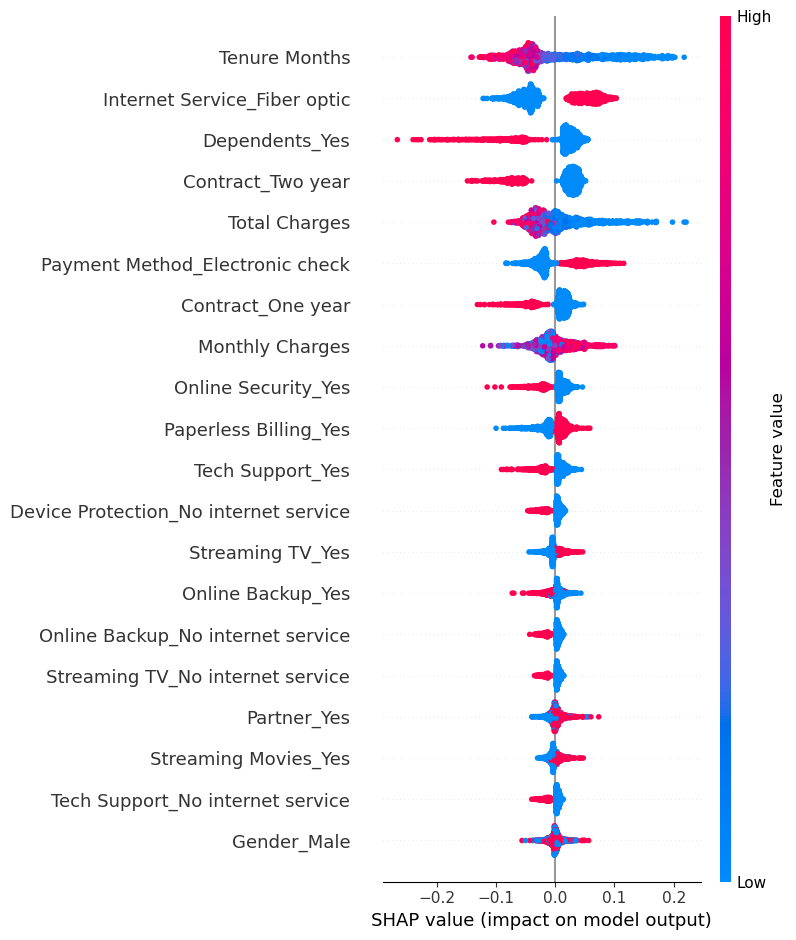

In [33]:
import shap
import numpy as np

# make sure all values are numeric
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)

# handle different SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 = churn
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]   # class 1
else:
    sv = shap_values

shap.summary_plot(sv, X_test_shap)

## 9. Bias Analysis

In [34]:
bias_df = X_test.copy()
bias_df["Actual"] = y_test.values
bias_df["Predicted"] = y_pred

# Check prediction differences by gender
if "Gender_Male" in bias_df.columns:
    gender_bias = bias_df.groupby("Gender_Male")["Predicted"].mean()
    print("Average predicted churn by gender:")
    print(gender_bias)

Average predicted churn by gender:
Gender_Male
False    0.211063
True     0.217452
Name: Predicted, dtype: float64


The bias analysis examines whether the model predicts churn differently across demographic groups. In this case, the predictions were compared across gender categories. If large differences appear between groups, this could indicate potential bias in the model and would require further investigation.

## 10. Deployment Preparation

In [35]:
import joblib

# Save the trained model
joblib.dump(model, "churn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [36]:
def predict_churn(new_customer_data):
    prediction = model.predict(new_customer_data)
    probability = model.predict_proba(new_customer_data)[:, 1]

    return pd.DataFrame({
        "Prediction": prediction,
        "Churn_Probability": probability
    })

The trained model is saved as a serialized file so it can be reused later without retraining. A scoring function is also provided to generate churn predictions and probabilities for new customer data. This prepares the model for potential deployment in a business application.

In [43]:
df_merged.to_csv("../dashboard/telecom_churn_dashboard.csv", index=False)